In [54]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split

In [55]:
ldf = pd.read_csv("linear_data.csv")
ldf.head()

,x,y
0,0.00000,4.447692
1,0.02004,5.024612
2,0.04008,5.869593
3,0.06012,4.722490
4,0.08016,4.877101


In [56]:
ldf.isna().sum()

x    0
y    0
dtype: int64

In [57]:
ldf.shape

(500, 2)

In [58]:
x = ldf[['x']]
y = ldf[['y']]

In [59]:
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.1, random_state=42)

In [60]:
lr = LinearRegression()
l_model = lr.fit(xtrain, ytrain)
print(f'Train score: {l_model.score(xtrain, ytrain)}')
print(f'Test score: {l_model.score(xtest, ytest)}')

Train score: 0.9926472845015207
Test score: 0.9943060811648443


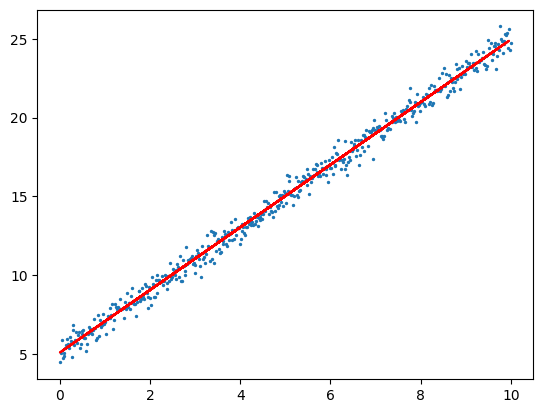

In [61]:
plt.scatter(ldf['x'], ldf['y'], s=2)
l_pred = l_model.predict(xtest)
plt.plot(xtest, l_pred, color='red')

In [62]:
nldf = pd.read_csv("nonlinear_data.csv")
nldf.head()

,x,y
0,0.00000,-0.155043
1,0.02004,0.081809
2,0.04008,-0.014298
3,0.06012,0.143978
4,0.08016,0.019553


In [65]:
X = nldf[['x']]
Y = nldf[['y']]

In [66]:
Xtrain, Xtest, Ytrain, Ytest = train_test_split(X, Y, test_size=0.1, random_state=42)

In [67]:
nl_model = lr.fit(Xtrain, Ytrain)
print(f'Train score: {nl_model.score(Xtrain, Ytrain)}')
print(f'Test score: {nl_model.score(Xtest, Ytest)}')

Train score: 0.003668731336979314
Test score: -0.12986689105972293


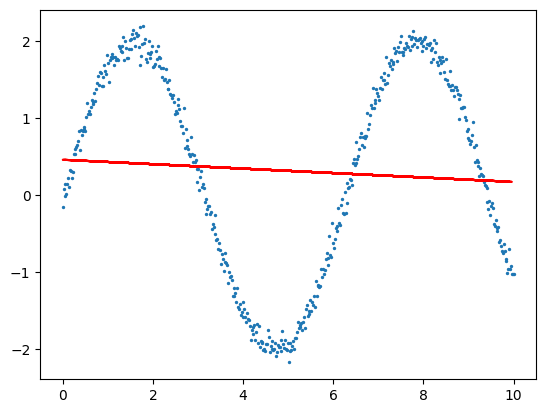

In [69]:
plt.scatter(nldf['x'], nldf['y'], s=2)
nl_pred = nl_model.predict(Xtest)
plt.plot(Xtest, nl_pred, color='red')

In [70]:
poly = PolynomialFeatures()
new_x = poly.fit_transform(X)
new_x

array([[1.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [1.00000000e+00, 2.00400802e-02, 4.01604813e-04],
       [1.00000000e+00, 4.00801603e-02, 1.60641925e-03],
       ...,
       [1.00000000e+00, 9.95991984e+00, 9.92000032e+01],
       [1.00000000e+00, 9.97995992e+00, 9.95996000e+01],
       [1.00000000e+00, 1.00000000e+01, 1.00000000e+02]], shape=(500, 3))

In [71]:
data = pd.DataFrame(new_x)
data

,0,1,2
0,1.0,0.00000,0.000000
1,1.0,0.02004,0.000402
2,1.0,0.04008,0.001606
3,1.0,0.06012,0.003614
4,1.0,0.08016,0.006426
...,...,...,...
495,1.0,9.91984,98.403219
496,1.0,9.93988,98.801210
497,1.0,9.95992,99.200003
498,1.0,9.97996,99.599600


In [72]:
x_train, x_test, y_train, y_test = train_test_split(data, Y, test_size=0.1, random_state=42)

In [74]:
p_model = lr.fit(x_train, y_train)
print(f"Train Score: {p_model.score(x_train, y_train)}")
print(f'Test Score: {p_model.score(x_test, y_test)}')

Train Score: 0.2234239772487654
Test Score: -0.4244689218469948
